In [1]:
import tensorflow as tensf
tensf.test.gpu_device_name()

'/device:GPU:0'

In [2]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 14794045971599846280
 xla_global_id: -1,
 name: "/device:GPU:0"
 device_type: "GPU"
 memory_limit: 14426112000
 locality {
   bus_id: 1
   links {
   }
 }
 incarnation: 10253560121332740922
 physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
 xla_global_id: 416903419]

In [ ]:
#memory info of the colab system
!cat /proc/meminfo

MemTotal:       13290480 kB
MemFree:         8243076 kB
MemAvailable:   12010092 kB
Buffers:          215544 kB
Cached:          3746584 kB
SwapCached:            0 kB
Active:           489684 kB
Inactive:        4168184 kB
Active(anon):       1088 kB
Inactive(anon):   706288 kB
Active(file):     488596 kB
Inactive(file):  3461896 kB
Unevictable:           4 kB
Mlocked:               4 kB
SwapTotal:             0 kB
SwapFree:              0 kB
Dirty:              9196 kB
Writeback:             0 kB
AnonPages:        693748 kB
Mapped:           724836 kB
Shmem:             11604 kB
KReclaimable:     114924 kB
Slab:             161192 kB
SReclaimable:     114924 kB
SUnreclaim:        46268 kB
KernelStack:        4804 kB
PageTables:         9112 kB
SecPageTables:         0 kB
NFS_Unstable:          0 kB
Bounce:                0 kB
WritebackTmp:          0 kB
CommitLimit:     6645240 kB
Committed_AS:    2617708 kB
VmallocTotal:   34359738367 kB
VmallocUsed:       79188 kB
VmallocChunk:    

In [ ]:
from google.colab import files as FILE
FILE.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shivaramvennam","key":"78f08fc0d7da9fb7d6e4a98c87b1889c"}'}

In [ ]:
!mkdir ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d gauravsahani/indian-currency-notes-classifier

 55% 11.0M/20.0M [00:00<00:00, 47.0MB/s]
100% 20.0M/20.0M [00:00<00:00, 68.7MB/s]


In [ ]:
!unzip indian-currency-notes-classifier.zip

Archive:  indian-currency-notes-classifier.zip
  inflating: Test/1Hundrednote/1.jpg  
  inflating: Test/1Hundrednote/14.jpg  
  inflating: Test/1Hundrednote/15.jpg  
  inflating: Test/1Hundrednote/16.jpg  
  inflating: Test/1Hundrednote/2.jpg  
  inflating: Test/1Hundrednote/3.jpg  
  inflating: Test/2Hundrednote/1.jpg  
  inflating: Test/2Hundrednote/2.jpg  
  inflating: Test/2Hundrednote/3.jpg  
  inflating: Test/2Hundrednote/31.jpg  
  inflating: Test/2Hundrednote/32.jpg  
  inflating: Test/2Hundrednote/33.jpg  
  inflating: Test/2Thousandnote/1.jpg  
  inflating: Test/2Thousandnote/2.jpg  
  inflating: Test/2Thousandnote/3.jpg  
  inflating: Test/2Thousandnote/31.jpg  
  inflating: Test/2Thousandnote/32.jpg  
  inflating: Test/2Thousandnote/33.jpg  
  inflating: Test/5Hundrednote/1.jpg  
  inflating: Test/5Hundrednote/2.jpg  
  inflating: Test/5Hundrednote/3.jpg  
  inflating: Test/5Hundrednote/31.jpg  
  inflating: Test/5Hundrednote/32.jpg  
  inflating: Test/5Hundrednote/33.jpg  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image

In [ ]:
import os

In [ ]:
plt.style.use("ggplot")
%matplotlib inline

In [ ]:
main_train_dir = os.path.join("Train/")
main_test_dir = os.path.join("Test/")

print(main_train_dir)
print(main_test_dir)

Train/
Test/


In [ ]:
two_thousand_dir = os.path.join("Train/2Thousandnote/")
five_hundered_dir = os.path.join("Train/5Hundrednote/")
two_hundered_dir = os.path.join("Train/2Hundrednote/")
one_hundered_dir = os.path.join("Train/1Hundrednote/")
fifty_dir = os.path.join("Train/Fiftynote/")
twenty_dir = os.path.join("Train/Twentynote/")
ten_dir = os.path.join("Train/Tennote/")

In [ ]:
two_thousand_names = os.listdir(two_thousand_dir)
five_hundered_names = os.listdir(five_hundered_dir)
two_hundered_names = os.listdir(two_hundered_dir)
one_hundered_names = os.listdir(one_hundered_dir)
fifty_names = os.listdir(fifty_dir)
twenty_names = os.listdir(twenty_dir)
ten_names = os.listdir(ten_dir)


print(two_thousand_names[:10])
print(five_hundered_names[:10])
print(two_hundered_names[:10])
print(one_hundered_names[:10])
print(fifty_names[:10])
print(twenty_names[:10])
print(ten_names[:10])

['10.jpg', '26.jpg', '8.jpg', '29.jpg', '11.jpg', '4.jpg', '12.jpg', '16.jpg', '1.jpg', '6.jpg']
['5.jpg', '3.jpg', '23.jpg', '26.jpg', '8.jpg', '29.jpg', '4.jpg', '9.jpg', '12.jpg', '16.jpg']
['5.jpg', '10.jpg', '30.jpg', '26.jpg', '8.jpg', '29.jpg', '11.jpg', '4.jpg', '12.jpg', '18.jpg']
['5.jpg', '10.jpg', '30.jpg', '3.jpg', '23.jpg', '8.jpg', '29.jpg', '11.jpg', '4.jpg', '18.jpg']
['3.jpg', '31.jpg', '23.jpg', '26.jpg', '8.jpg', '11.jpg', '12.jpg', '16.jpg', '18.jpg', '1.jpg']
['10.jpg', '32.jpg', '3.jpg', '23.jpg', '26.jpg', '8.jpg', '29.jpg', '11.jpg', '4.jpg', '9.jpg']
['5.jpg', '10.jpg', '30.jpg', '3.jpg', '26.jpg', '4.jpg', '12.jpg', '16.jpg', '18.jpg', '1.jpg']


In [ ]:
print(f"total training of 2Thousand Notes : {len(two_thousand_names)}")
print(f"total training of 5Hundered Notes : {len(five_hundered_names)}")
print(f"total training of 2Hundered Notes : {len(two_hundered_names)}")
print(f"total training of 1Hundered Notes: {len(one_hundered_names)}")
print(f"total training of 50Notes : {len(fifty_names)}")
print(f"total training of 20Notes : {len(twenty_names)}")
print(f"total training of 10Notes : {len(ten_names)}")

total training of 2Thousand Notes : 21
total training of 5Hundered Notes : 22
total training of 2Hundered Notes : 22
total training of 1Hundered Notes: 22
total training of 50Notes : 22
total training of 20Notes : 22
total training of 10Notes : 22


In [ ]:
# parameters for graph we'll output images in a 4x4
nrows = 4
ncols = 4

# Index for iterating over images
pic_index = 0

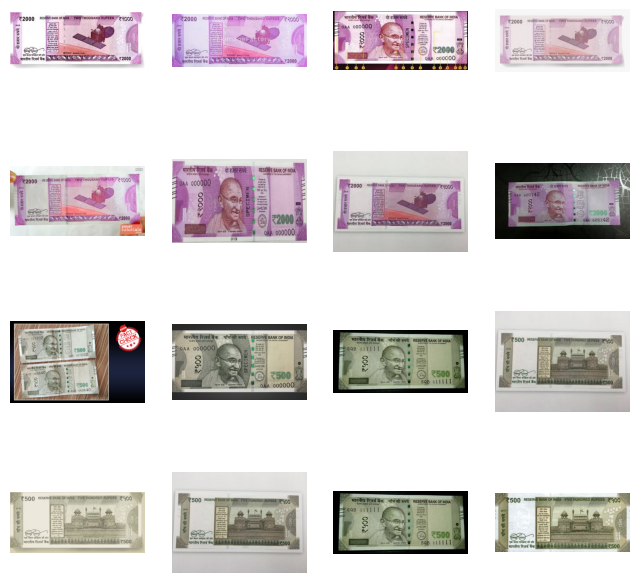

In [ ]:
# set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols * 2, nrows * 2)

pic_index += 8

two_thousand_pix = [os.path.join(two_thousand_dir, fname)
                for fname in two_thousand_names[pic_index-8:pic_index]]

five_hundered_pix = [os.path.join(five_hundered_dir, fname)
                for fname in five_hundered_names[pic_index-8:pic_index]]


for i, img in enumerate(two_thousand_pix + five_hundered_pix):
    sub_plot = plt.subplot(nrows, ncols, i + 1)
    sub_plot.axis("Off")
    img_read = mpimg.imread(img)
    plt.imshow(img_read)

plt.show()

#CNN

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(7, activation="softmax")
])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 36, 36, 32)        0         
 g2D)                                                            
                                                                 
 dropout (Dropout)           (None, 36, 36, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 64)        1

In [ ]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
train_datagen = ImageDataGenerator(rescale=1/255)
validation_datagen = ImageDataGenerator(rescale=1/255)

# Flow training images in batches of 128 using train_datagen generator
train_generator = train_datagen.flow_from_directory(main_train_dir,
                                                   batch_size=64,
                                                   target_size=(150,150),
                                                   class_mode="categorical")

validation_generator = validation_datagen.flow_from_directory(main_test_dir,
                                                             batch_size=16,
                                                              target_size=(150,150),
                                                             class_mode="categorical")

Found 153 images belonging to 7 classes.
Found 42 images belonging to 7 classes.


In [ ]:
history = model.fit(train_generator,
                    epochs=100,
                    steps_per_epoch=len(train_generator),
                    verbose=1,
                    validation_data=validation_generator,
                    validation_steps=len(validation_generator))

Epoch 1/100
3/3 [==============================] - 11s 1s/step - loss: 2.0122 - accuracy: 0.1111 - val_loss: 1.9482 - val_accuracy: 0.2143
Epoch 2/100
3/3 [==============================] - 1s 329ms/step - loss: 1.9491 - accuracy: 0.1830 - val_loss: 1.9342 - val_accuracy: 0.2857
Epoch 3/100
3/3 [==============================] - 1s 324ms/step - loss: 1.9229 - accuracy: 0.2222 - val_loss: 1.8976 - val_accuracy: 0.3810
Epoch 4/100
3/3 [==============================] - 1s 313ms/step - loss: 1.8776 - accuracy: 0.3137 - val_loss: 1.8284 - val_accuracy: 0.3810
Epoch 5/100
3/3 [==============================] - 1s 430ms/step - loss: 1.7752 - accuracy: 0.3464 - val_loss: 1.7028 - val_accuracy: 0.2857
Epoch 6/100
3/3 [==============================] - 1s 350ms/step - loss: 1.6364 - accuracy: 0.3791 - val_loss: 1.6306 - val_accuracy: 0.3333
Epoch 7/100
3/3 [==============================] - 1s 299ms/step - loss: 1.6113 - accuracy: 0.3268 - val_loss: 1.5022 - val_accuracy: 0.4048
Epoch 8/100
3/3

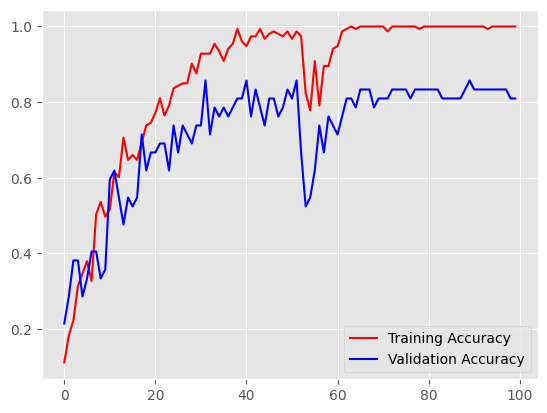

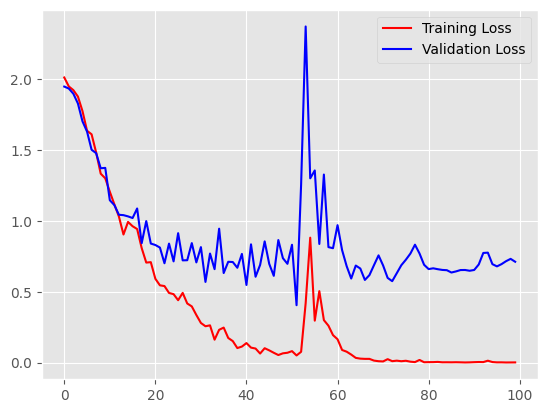

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(acc))

plt.plot(epochs, acc, "r", label="Training Accuracy")
plt.plot(epochs, val_acc, "b", label="Validation Accuracy")

plt.legend()
plt.figure()

plt.plot(epochs, loss, "r", label="Training Loss")
plt.plot(epochs, val_loss, "b", label="Validation Loss")

plt.legend()
plt.show()

1/1 [==============================] - 0s 375ms/step
Test/1Hundrednote/1.jpg is Ten Rupees


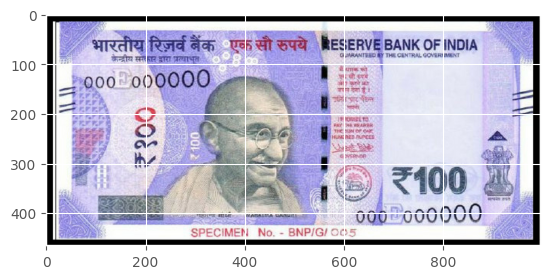

In [ ]:
path = "Test/1Hundrednote/1.jpg"
img = image.load_img(path, target_size=(150, 150))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

images = np.vstack([x])
classes = model.predict(images, batch_size=10)
classes = np.argmax(classes,axis=1)


if classes[0] == 1:
    print(path + " is Two Thousand Rupees")
elif classes[0] == 2:
    print(path + " is Five Hundered Rupees")
elif classes[0] == 3:
    print(path + " is Two Hundered Rupees")
elif classes[0] == 4:
    print(path, + " is One Hundered Rupees")
elif classes[0] == 5:
    print(path + "is Fifty Rupees")
elif classes[0] == 6:
    print(path + " is Twenty Rupees")
else:
    print(path + " is Ten Rupees")

img = mpimg.imread(path)
plt.imshow(img)
plt.show()